In [4]:
!pip install pandas numpy matplotlib seaborn ta-lib pynance


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\user\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import talib
import os

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported and ready!")

Libraries imported and ready!


In [10]:
# Load news data
# Make sure raw_analyst_ratings.csv is in your data/raw folder
news_path = '../data/raw/raw_analyst_ratings.csv'

if os.path.exists(news_path):
    news_df = pd.read_csv(news_path)
    
    # Convert date to datetime objects
    news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce')
    
    # Statistics for textual lengths
    news_df['headline_len'] = news_df['headline'].apply(len)
    print(f"Average Headline Length: {news_df['headline_len'].mean():.2f}")
    print(news_df['headline_len'].describe())

    # Count articles per publisher
    publisher_counts = news_df['publisher'].value_counts().head(10)
    print("\nTop 10 Publishers:")
    print(publisher_counts)

    # Visualization 1: Headline Length Distribution
    plt.figure(figsize=(10, 5))
    sns.histplot(news_df['headline_len'], bins=50, kde=True, color='teal')
    plt.title('Distribution of Headline Character Counts')
    plt.xlabel('Character Count')
    plt.show()
else:
    print("News file not found. Please check your data/raw/ directory.")

News file not found. Please check your data/raw/ directory.


In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Define path
news_path = '../data/raw/raw_analyst_ratings.csv'

# Load and basic cleaning
df = pd.read_csv(news_path)
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# 1. Headline Length Analysis
df['headline_len'] = df['headline'].apply(len)
print(f"Average Headline Length: {df['headline_len'].mean():.2f}")

# 2. Publisher Activity
top_publishers = df['publisher'].value_counts().head(10)
print("\nTop 10 Publishers:")
print(top_publishers)

# Visualization: Distribution of Headline Lengths
plt.figure(figsize=(10, 6))
sns.histplot(df['headline_len'], bins=50, kde=True, color='teal')
plt.title('Distribution of News Headline Lengths')
plt.xlabel('Characters')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/raw_analyst_ratings.csv'

In [12]:
import os
# Check what is actually inside the folder
print("Files in data/raw:", os.listdir('../data/raw/'))

FileNotFoundError: [WinError 3] The system cannot find the path specified: '../data/raw/'

In [13]:
import os

# 1. Show current location
current = os.getcwd()
print(f"I am currently here: {current}")

# 2. List folders in the current directory
print(f"Folders here: {os.listdir('.')}")

# 3. Check if 'data' exists one level up
parent_dir = os.path.abspath(os.path.join(current, '..'))
print(f"Parent directory: {parent_dir}")
if os.path.exists(parent_dir):
    print(f"Folders in Parent: {os.listdir(parent_dir)}")

I am currently here: C:\Users\user\Documents\GitHub\news-sentiment-analysis
Folders here: ['.git', '.github', '.gitignore', '.ipynb_checkpoints', 'data', 'EDA_News.ipynb', 'notebooks', 'README.md', 'requirements.txt', 'scripts', 'src', 'tests', 'Untitled.ipynb']
Parent directory: C:\Users\user\Documents\GitHub
Folders in Parent: ['news-sentiment-analysis']


In [15]:
# No dots needed because you are already in the project root!
news_path = 'data/raw/raw_analyst_ratings.csv'
stock_path = 'data/raw/AAPL.csv'

In [16]:
import os
target_dir = 'data/raw'
if os.path.exists(target_dir):
    print("Files found:", os.listdir(target_dir))
else:
    print("The 'data/raw' folder still doesn't exist. Run 'mkdir data\\raw' in terminal.")

Files found: ['raw_analyst_ratings.csv']


Headline Length Statistics:
count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_len, dtype: float64

Top 10 Publishers by Article Count:
publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64


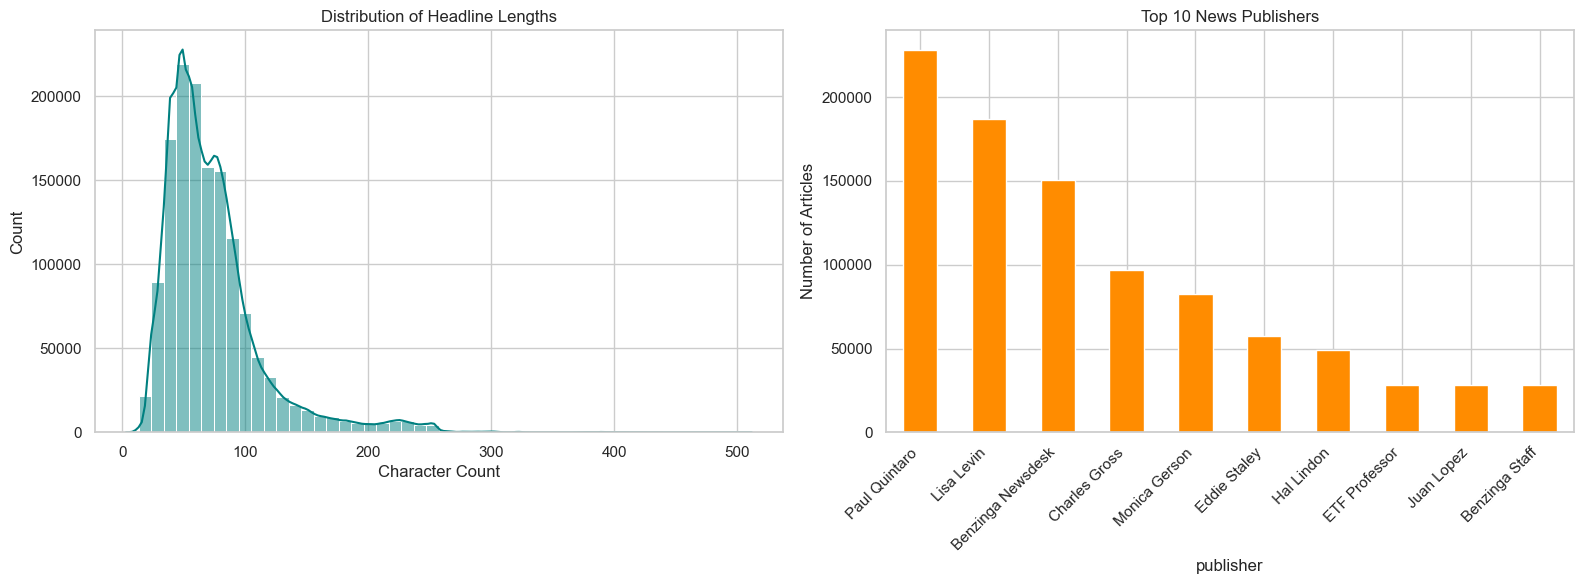

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the news data
df = pd.read_csv('data/raw/raw_analyst_ratings.csv')

# Ensure the date column is in datetime format
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# --- Requirement: Headline Length Analysis ---
df['headline_len'] = df['headline'].apply(len)
print("Headline Length Statistics:")
print(df['headline_len'].describe())

# --- Requirement: Publisher Analysis ---
publisher_counts = df['publisher'].value_counts().head(10)
print("\nTop 10 Publishers by Article Count:")
print(publisher_counts)

# --- Visualizations ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Headline Length Distribution
sns.histplot(df['headline_len'], bins=50, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution of Headline Lengths')
axes[0].set_xlabel('Character Count')

# Plot 2: Top Publishers Bar Chart
publisher_counts.plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Top 10 News Publishers')
axes[1].set_ylabel('Number of Articles')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

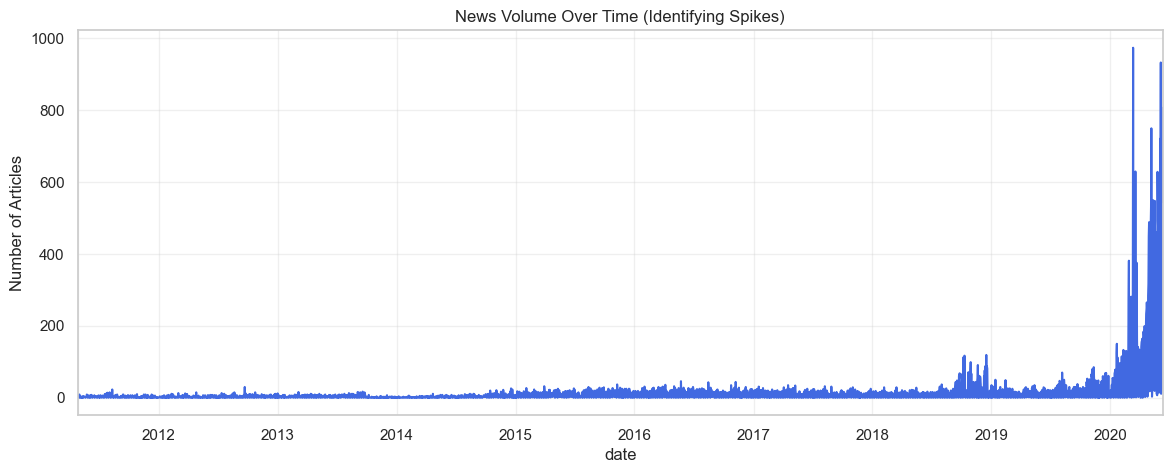

In [18]:
# Group by day to see the volume of news over time
daily_counts = df.resample('D', on='date').size()

plt.figure(figsize=(14, 5))
daily_counts.plot(color='royalblue')
plt.title('News Volume Over Time (Identifying Spikes)')
plt.ylabel('Number of Articles')
plt.grid(alpha=0.3)
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_8276\3428765945.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=sample_df, x='sentiment_class', palette='viridis')


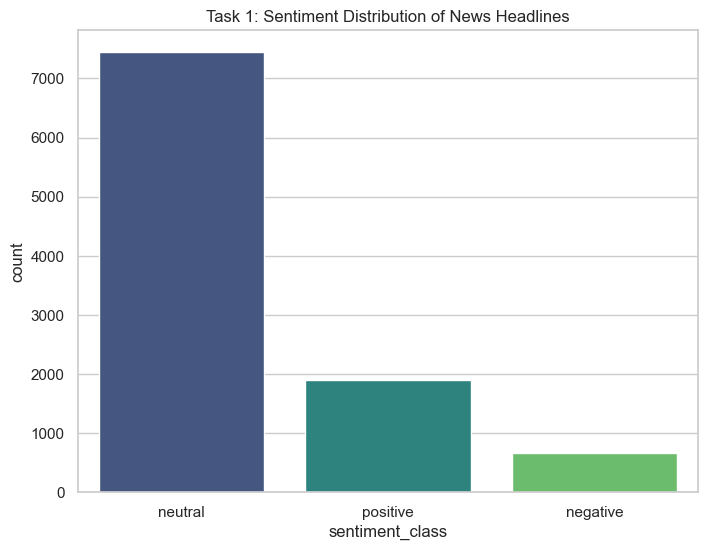

Sentiment Analysis complete!
sentiment_class
neutral     7449
positive    1888
negative     663
Name: count, dtype: int64


In [24]:
from textblob import TextBlob

# Since 1.4M rows is huge, let's take a sample of 10,000 to get a quick idea
# Or remove '.sample(10000)' to run it on everything (might take 2-5 minutes)
sample_df = df.sample(10000).copy()

def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

# Apply sentiment analysis
sample_df['sentiment'] = sample_df['headline'].apply(get_sentiment)

# Categorize sentiment
sample_df['sentiment_class'] = sample_df['sentiment'].apply(
    lambda x: 'positive' if x > 0.1 else ('negative' if x < -0.1 else 'neutral')
)

# Plot the results
plt.figure(figsize=(8, 6))
sns.countplot(data=sample_df, x='sentiment_class', palette='viridis')
plt.title('Task 1: Sentiment Distribution of News Headlines')
plt.show()

print("Sentiment Analysis complete!")
print(sample_df['sentiment_class'].value_counts())

In [21]:
!pip install textblob

   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.0 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.0 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.0 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.0 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.0 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.0 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.0 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.0 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.0 kB ? 

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\user\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [23]:
import nltk
nltk.download('punkt_tab')
nltk.download('brown')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package brown to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package brown is already up-to-date!


True